# Détection d'intrusions réseau — CIC-IDS-2017
## Analyse complète des données (lues depuis HDFS)

Ce notebook lit le dataset unifié stocké sur **HDFS** (`/user/projet/unified_dataset.parquet`, produit par `process_data.py`) et réalise :
1. Statistiques descriptives complètes
2. Répartition des classes (attaques)
3. Détection de colonnes constantes / peu informatives
4. Analyse de la variabilité des variables
5. Détection des valeurs aberrantes (anomalies, méthode IQR)
6. Histogrammes, boxplots
7. Matrice de corrélation + détection des redondances
8. Sélection de variables justifiée

> **Prérequis** : Hadoop doit tourner (`jps` → 5 services).

## 1. Connexion à Spark et lecture des données HDFS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession

sns.set_theme(style="whitegrid")

spark = (SparkSession.builder
         .appName("Analyse CIC-IDS-2017")
         .config("spark.driver.memory", "4g")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

HDFS_PATH = "hdfs://localhost:9000/user/projet/unified_dataset.parquet"
df = spark.read.parquet(HDFS_PATH)

print(f"Nombre de lignes   : {df.count():,}")
print(f"Nombre de colonnes : {len(df.columns)}")

26/07/02 05:29:15 WARN Utils: Your hostname, nina resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/07/02 05:29:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/02 05:29:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Nombre de lignes   : 2,830,743
Nombre de colonnes : 79


In [2]:
# Aperçu du schéma (5 premières colonnes + Label)
df.select(df.columns[:5] + ["Label"]).show(5, truncate=False)

+----------------+-------------+-----------------+----------------------+---------------------------+------+
|Destination Port|Flow Duration|Total Fwd Packets|Total Backward Packets|Total Length of Fwd Packets|Label |
+----------------+-------------+-----------------+----------------------+---------------------------+------+
|88              |640          |7                |4                     |440                        |BENIGN|
|88              |900          |9                |4                     |600                        |BENIGN|
|88              |1205         |7                |4                     |2776                       |BENIGN|
|88              |511          |7                |4                     |452                        |BENIGN|
|88              |773          |9                |4                     |612                        |BENIGN|
+----------------+-------------+-----------------+----------------------+---------------------------+------+
only showing top 5 

## 2. Répartition des classes (types d'attaques)

Le dataset est fortement **déséquilibré** : la grande majorité du trafic est normal (`BENIGN`).
Ce déséquilibre est typique en cybersécurité et devra être pris en compte lors de l'entraînement du modèle.

In [3]:
# Comptage par classe côté Spark (sur la totalité des données)
dist = (df.groupBy("Label").count()
          .orderBy("count", ascending=False)
          .toPandas())
dist["pourcentage"] = (dist["count"] / dist["count"].sum() * 100).round(3)
dist

,Label,count,pourcentage
0,BENIGN,2273097,80.300
1,DoS Hulk,231073,8.163
2,PortScan,158930,5.614
3,DDoS,128027,4.523
4,DoS GoldenEye,10293,0.364
5,FTP-Patator,7938,0.280
6,SSH-Patator,5897,0.208
7,DoS slowloris,5796,0.205
8,DoS Slowhttptest,5499,0.194
9,Bot,1966,0.069


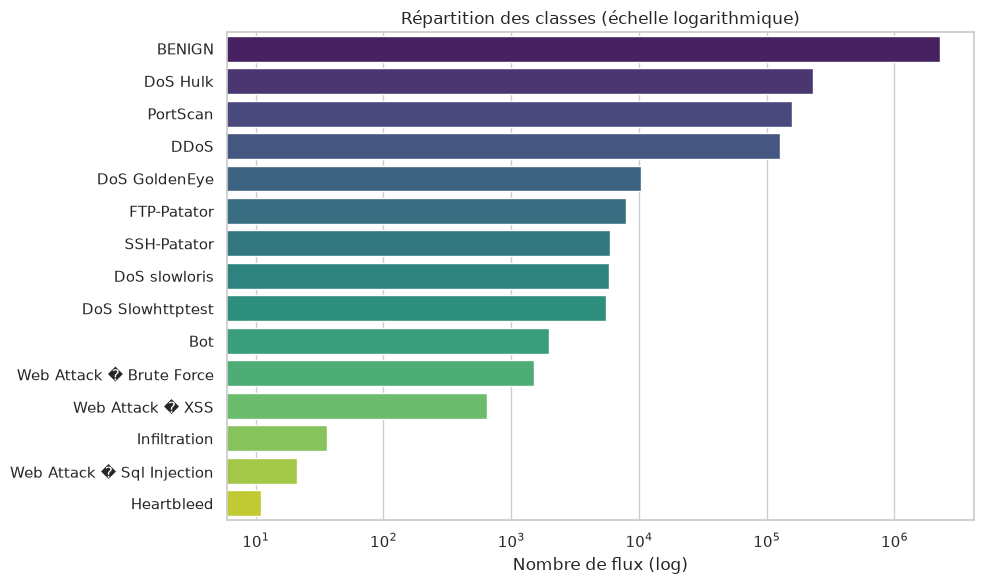

In [4]:
plt.figure(figsize=(10, 6))
sns.barplot(data=dist, y="Label", x="count", hue="Label", palette="viridis", legend=False)
plt.xscale("log")  # échelle log car BENIGN écrase les autres classes
plt.title("Répartition des classes (échelle logarithmique)")
plt.xlabel("Nombre de flux (log)")
plt.ylabel("")
plt.tight_layout()
plt.show()

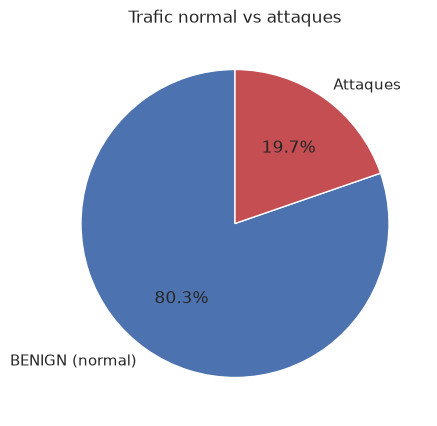

Normal : 2,273,097  |  Attaques : 557,646  (19.7% d'attaques)


In [5]:
# Vue binaire : trafic normal vs attaque
normal = dist.loc[dist["Label"] == "BENIGN", "count"].sum()
attaque = dist.loc[dist["Label"] != "BENIGN", "count"].sum()
plt.figure(figsize=(5, 5))
plt.pie([normal, attaque], labels=["BENIGN (normal)", "Attaques"],
        autopct="%1.1f%%", colors=["#4c72b0", "#c44e52"], startangle=90)
plt.title("Trafic normal vs attaques")
plt.show()
print(f"Normal : {normal:,}  |  Attaques : {attaque:,}  ({attaque/(normal+attaque)*100:.1f}% d'attaques)")

## 3. Échantillon pour l'analyse détaillée

2,8 M de lignes, c'est trop pour pandas/matplotlib. On prend un **échantillon de 5 %** (~140 000 lignes)
ramené en pandas, avec **toutes les colonnes numériques**, en nettoyant les valeurs infinies.

In [6]:
feature_cols = [c for c in df.columns if c != "Label"]
pdf = (df.select(feature_cols + ["Label"])
         .sample(fraction=0.05, seed=42)
         .toPandas())

# Conversion en numérique + remplacement des infinis par NaN
for c in feature_cols:
    pdf[c] = pd.to_numeric(pdf[c], errors="coerce")
pdf = pdf.replace([np.inf, -np.inf], np.nan)
pdf["type"] = np.where(pdf["Label"] == "BENIGN", "Normal", "Attaque")

numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(pdf[c])]
print(f"Échantillon : {len(pdf):,} lignes | {len(numeric_cols)} colonnes numériques")

Échantillon : 142,087 lignes | 78 colonnes numériques


## 4. Statistiques descriptives complètes

Moyenne, écart-type, min, max et quartiles (25 %, 50 % = médiane, 75 %) pour les variables clés.

In [7]:
key_features = [c for c in [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Flow Bytes/s", "Flow Packets/s", "Fwd Packet Length Mean",
    "Bwd Packet Length Mean", "Average Packet Size",
    "Packet Length Mean", "Destination Port",
] if c in numeric_cols]

pdf[key_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Flow Duration,142087.0,14743818.59,33611044.43,-1.0,154.00,31213.00,3168822.00,1.200000e+08
Total Fwd Packets,142087.0,10.60,872.09,1.0,2.00,2.00,5.00,2.197590e+05
Total Backward Packets,142087.0,12.09,1178.25,0.0,1.00,2.00,4.00,2.919220e+05
Flow Bytes/s,141943.0,1427265.05,25299993.41,-12000000.0,119.47,4661.87,166666.67,2.071000e+09
Flow Packets/s,141943.0,70501.14,253436.15,-2000000.0,3.46,115.59,23255.81,3.000000e+06
Fwd Packet Length Mean,142087.0,57.39,183.40,0.0,6.00,34.00,50.00,5.238770e+03
Bwd Packet Length Mean,142087.0,304.34,603.28,0.0,2.00,72.00,180.00,3.927260e+03
Average Packet Size,142087.0,190.73,330.76,0.0,7.50,72.00,148.39,2.920000e+03
Packet Length Mean,142087.0,170.85,304.69,0.0,6.00,56.80,118.67,2.595560e+03
Destination Port,142087.0,8063.49,18272.83,0.0,53.00,80.00,443.00,6.552200e+04


## 5. Colonnes constantes ou peu informatives

Une colonne qui ne prend qu'**une seule valeur** (variance nulle) n'apporte aucune information
au modèle : elle peut être supprimée.

In [8]:
const_cols = [c for c in numeric_cols if pdf[c].nunique(dropna=True) <= 1]
print(f"Colonnes constantes détectées : {len(const_cols)}")
for c in const_cols:
    val = pdf[c].dropna().unique()
    print(f"  - {c}  (valeur unique : {val[:1]})")

Colonnes constantes détectées : 8
  - Bwd PSH Flags  (valeur unique : [0])
  - Bwd URG Flags  (valeur unique : [0])
  - Fwd Avg Bytes/Bulk  (valeur unique : [0])
  - Fwd Avg Packets/Bulk  (valeur unique : [0])
  - Fwd Avg Bulk Rate  (valeur unique : [0])
  - Bwd Avg Bytes/Bulk  (valeur unique : [0])
  - Bwd Avg Packets/Bulk  (valeur unique : [0])
  - Bwd Avg Bulk Rate  (valeur unique : [0])


## 6. Variabilité des variables

On classe les variables par **coefficient de variation** (CV = écart-type / moyenne).
Un CV élevé = forte dispersion → souvent plus discriminant pour distinguer les attaques.

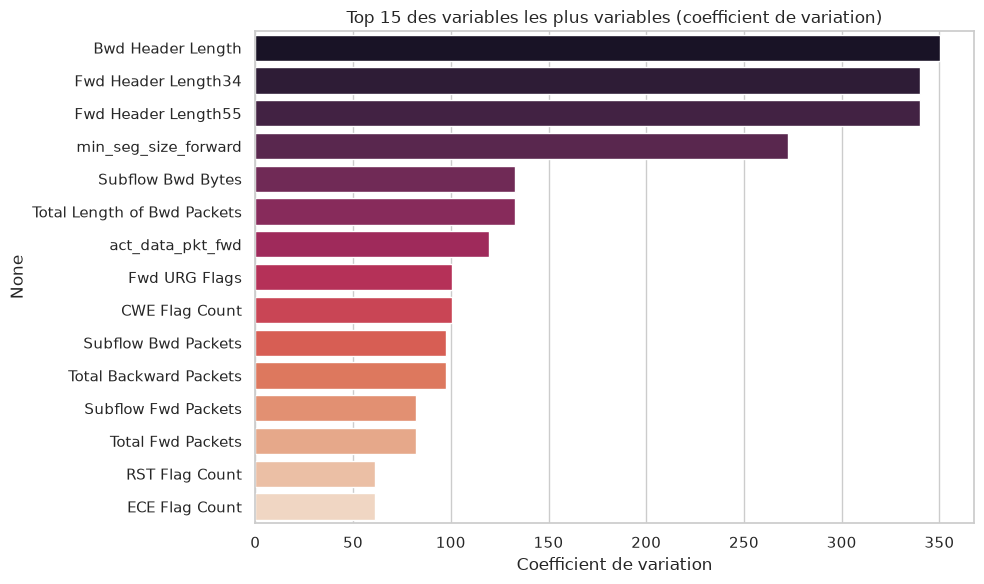

Bwd Header Length              350.18
Fwd Header Length34            340.09
Fwd Header Length55            340.09
min_seg_size_forward           272.57
Subflow Bwd Bytes              132.64
Total Length of Bwd Packets    132.62
act_data_pkt_fwd               119.72
Fwd URG Flags                  100.74
CWE Flag Count                 100.74
Subflow Bwd Packets             97.45
Total Backward Packets          97.45
Subflow Fwd Packets             82.26
Total Fwd Packets               82.26
RST Flag Count                  61.14
ECE Flag Count                  61.14
dtype: float64

In [9]:
desc = pdf[numeric_cols].describe().T
cv = (desc["std"] / desc["mean"].abs()).replace([np.inf, -np.inf], np.nan).dropna()
cv_top = cv.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=cv_top.values, y=cv_top.index, hue=cv_top.index, palette="rocket", legend=False)
plt.title("Top 15 des variables les plus variables (coefficient de variation)")
plt.xlabel("Coefficient de variation")
plt.tight_layout()
plt.show()
cv_top.round(2)

## 7. Détection des valeurs aberrantes (anomalies) — méthode IQR

Méthode de **l'écart interquartile (IQR)** : une valeur est aberrante si elle est en dehors de
`[Q1 - 1.5*IQR ; Q3 + 1.5*IQR]`. On calcule le **pourcentage d'anomalies** par variable.
Les variables riches en valeurs extrêmes correspondent souvent à des comportements d'attaque.

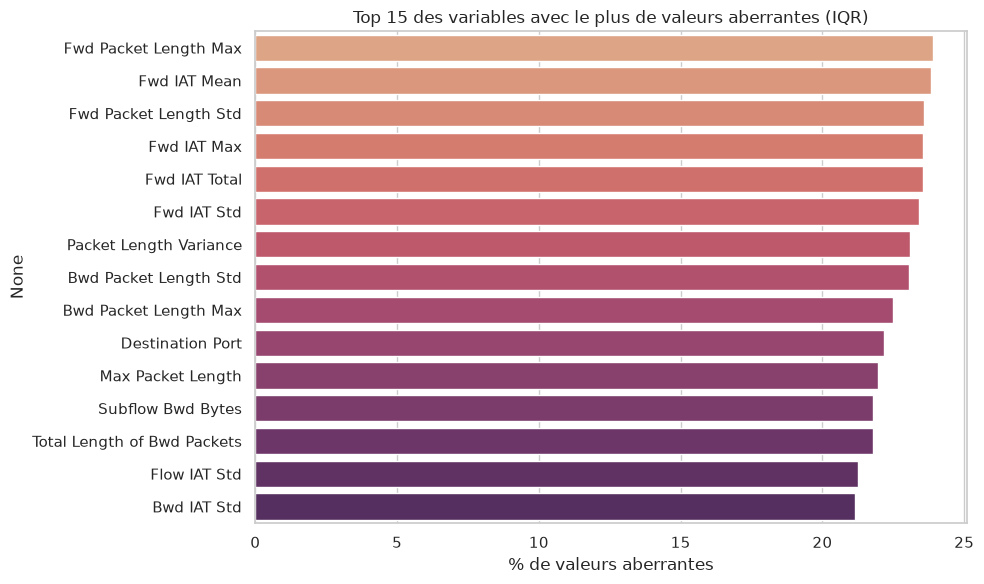

Fwd Packet Length Max          23.89
Fwd IAT Mean                   23.82
Fwd Packet Length Std          23.57
Fwd IAT Max                    23.56
Fwd IAT Total                  23.56
Fwd IAT Std                    23.40
Packet Length Variance         23.07
Bwd Packet Length Std          23.07
Bwd Packet Length Max          22.48
Destination Port               22.18
Max Packet Length              21.94
Subflow Bwd Bytes              21.80
Total Length of Bwd Packets    21.80
Flow IAT Std                   21.26
Bwd IAT Std                    21.15
dtype: float64

In [10]:
def pct_outliers(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        return 0.0
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).mean() * 100

outliers = pd.Series({c: pct_outliers(pdf[c]) for c in numeric_cols}).dropna()
out_top = outliers.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=out_top.values, y=out_top.index, hue=out_top.index, palette="flare", legend=False)
plt.title("Top 15 des variables avec le plus de valeurs aberrantes (IQR)")
plt.xlabel("% de valeurs aberrantes")
plt.tight_layout()
plt.show()
out_top.round(2)

## 8. Histogrammes des variables importantes

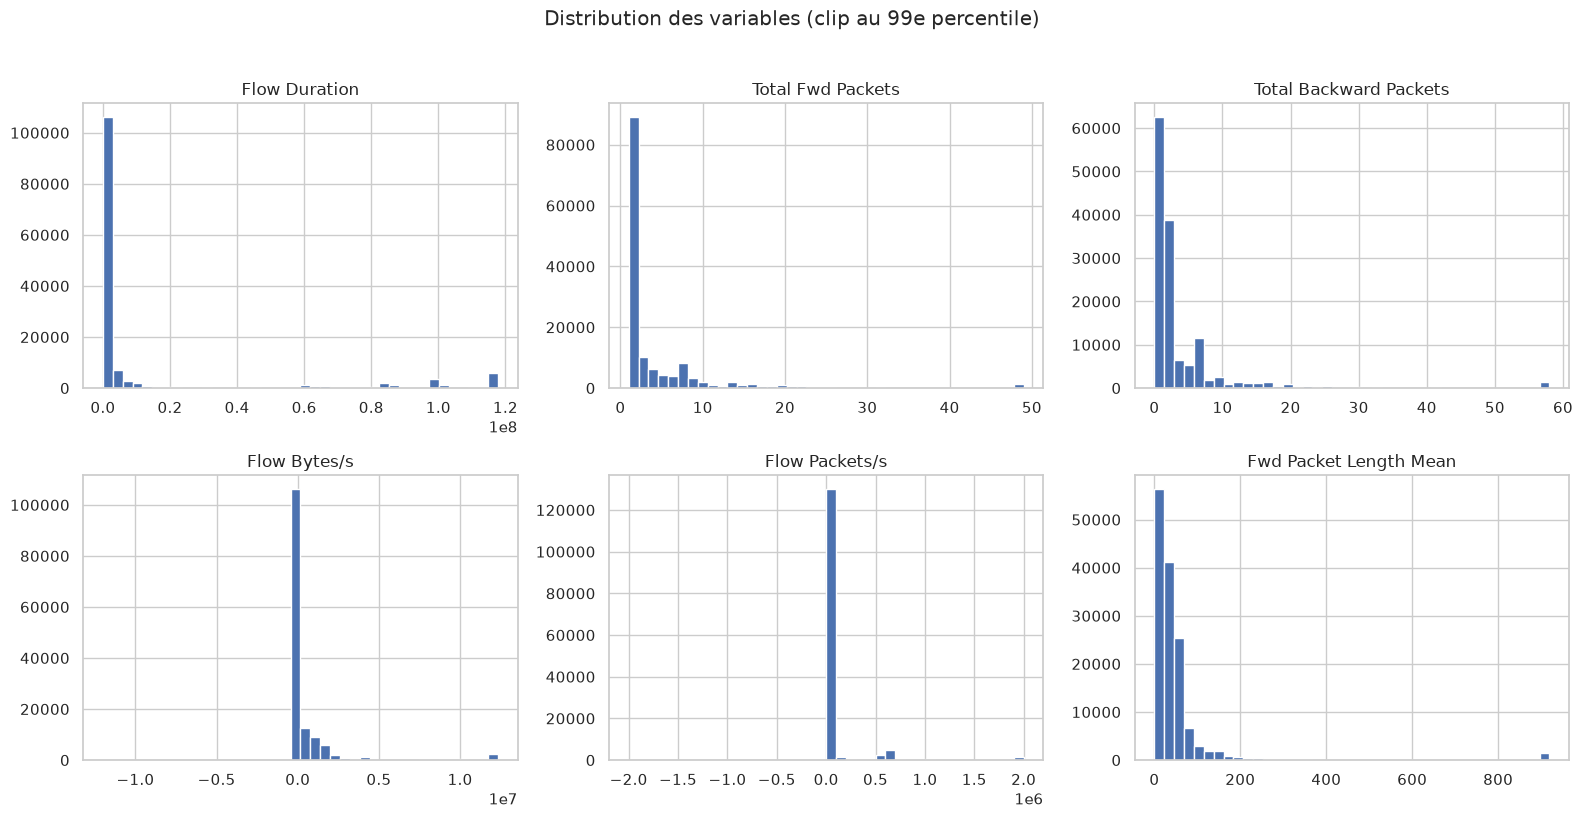

In [11]:
cols_hist = key_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), cols_hist):
    data = pdf[c].dropna()
    hi = data.quantile(0.99)  # clip au 99e percentile pour lisibilité
    ax.hist(data.clip(upper=hi), bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(c)
plt.suptitle("Distribution des variables (clip au 99e percentile)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Boxplots — Normal vs Attaque

Permet de voir quelles variables **séparent** le mieux le trafic normal des attaques,
et de visualiser directement les valeurs aberrantes (points au-delà des moustaches).

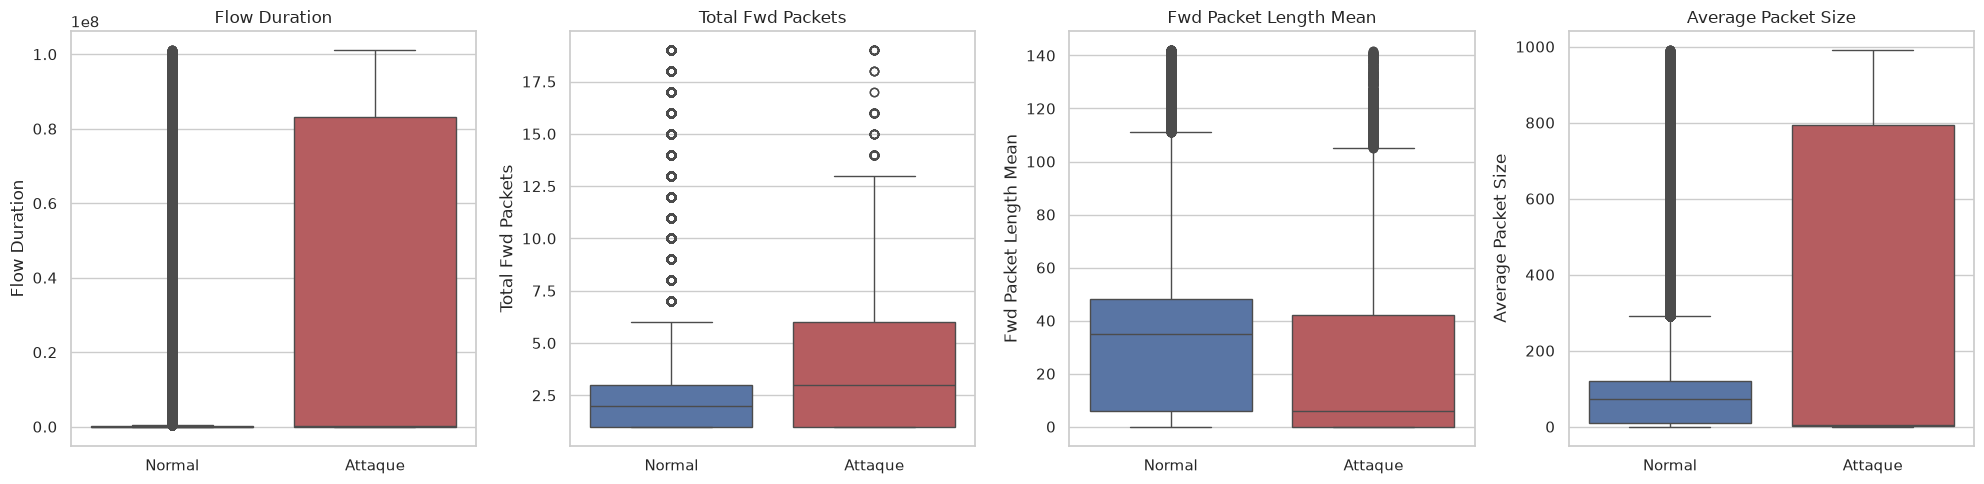

In [12]:
cols_box = [c for c in ["Flow Duration", "Total Fwd Packets", "Fwd Packet Length Mean", "Average Packet Size"] if c in key_features]
fig, axes = plt.subplots(1, len(cols_box), figsize=(5 * len(cols_box), 5))
for ax, c in zip(np.atleast_1d(axes), cols_box):
    d = pdf[[c, "type"]].dropna()
    hi = d[c].quantile(0.95)
    sns.boxplot(data=d[d[c] <= hi], x="type", y=c, hue="type",
                palette=["#4c72b0", "#c44e52"], legend=False, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 10. Matrice de corrélation et variables redondantes

Deux variables très corrélées (|r| > 0,9) sont **redondantes** : on peut en supprimer une
sans perte d'information.

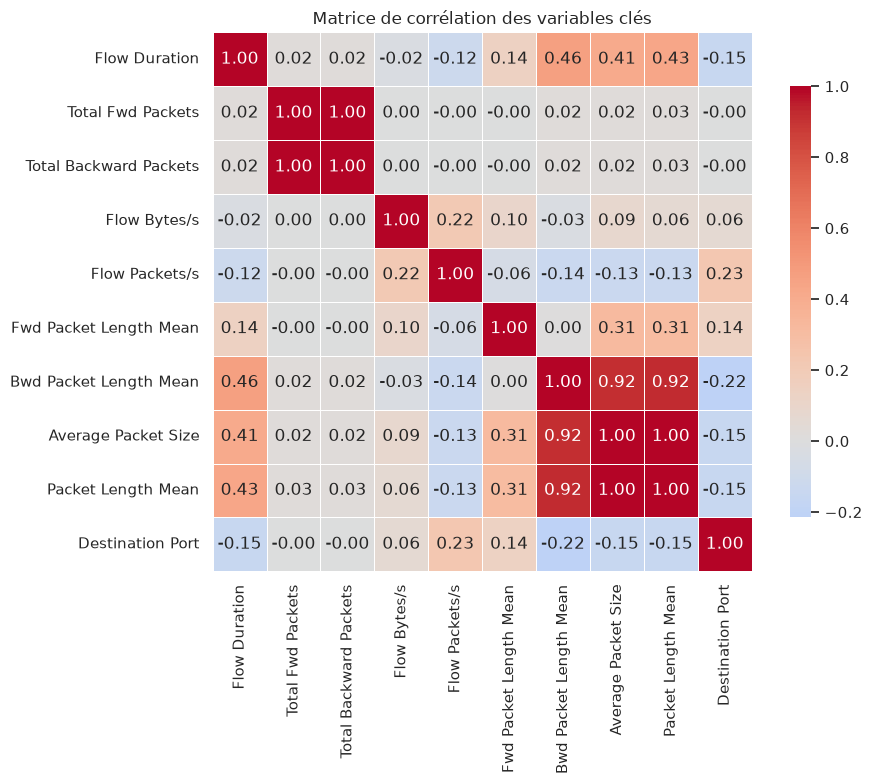

In [13]:
corr = pdf[key_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matrice de corrélation des variables clés")
plt.tight_layout()
plt.show()

In [14]:
# Détection automatique des paires redondantes (|corr| > 0.9) sur toutes les variables numériques
corr_all = pdf[numeric_cols].corr().abs()
mask = np.triu(np.ones(corr_all.shape), k=1).astype(bool)
upper = corr_all.where(mask)
pairs = [(i, j, round(upper.loc[i, j], 3))
         for i in upper.index for j in upper.columns
         if pd.notna(upper.loc[i, j]) and upper.loc[i, j] > 0.9]
red_df = pd.DataFrame(pairs, columns=["Variable A", "Variable B", "Corrélation"]).sort_values("Corrélation", ascending=False)
print(f"Paires redondantes (|corr| > 0.9) : {len(red_df)}")
red_df.head(20)

Paires redondantes (|corr| > 0.9) : 80


,Variable A,Variable B,Corrélation
1,Total Fwd Packets,Total Backward Packets,1.000
3,Total Fwd Packets,Subflow Fwd Packets,1.000
4,Total Fwd Packets,Subflow Bwd Packets,1.000
8,Total Backward Packets,Subflow Fwd Packets,1.000
12,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000
15,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000
9,Total Backward Packets,Subflow Bwd Packets,1.000
68,RST Flag Count,ECE Flag Count,1.000
51,Fwd PSH Flags,SYN Flag Count,1.000
54,Fwd Header Length34,Fwd Header Length55,1.000


## 11. Sélection de variables

On construit l'ensemble final de variables en **supprimant** :
- les colonnes **constantes** (aucune information),
- une variable de chaque **paire redondante** (corrélation > 0,9).

C'est cet ensemble réduit qui serait utilisé pour entraîner le modèle.

In [15]:
to_drop = set(const_cols)
for a, b, v in pairs:
    if a not in to_drop and b not in to_drop:
        to_drop.add(b)  # on garde A, on supprime B

kept = [c for c in numeric_cols if c not in to_drop]
print(f"Variables numériques initiales : {len(numeric_cols)}")
print(f"  - supprimées (constantes)     : {len(const_cols)}")
print(f"  - supprimées (redondantes)    : {len(to_drop) - len(const_cols)}")
print(f"  => Variables conservées       : {len(kept)}")
print()
print("Colonnes supprimées :")
for c in sorted(to_drop):
    raison = "constante" if c in const_cols else "redondante"
    print(f"  - {c}  ({raison})")

Variables numériques initiales : 78
  - supprimées (constantes)     : 8
  - supprimées (redondantes)    : 29
  => Variables conservées       : 41

Colonnes supprimées :
  - Average Packet Size  (redondante)
  - Avg Bwd Segment Size  (redondante)
  - Avg Fwd Segment Size  (redondante)
  - Bwd Avg Bulk Rate  (constante)
  - Bwd Avg Bytes/Bulk  (constante)
  - Bwd Avg Packets/Bulk  (constante)
  - Bwd Header Length  (redondante)
  - Bwd IAT Min  (redondante)
  - Bwd PSH Flags  (constante)
  - Bwd Packet Length Mean  (redondante)
  - Bwd Packet Length Std  (redondante)
  - Bwd URG Flags  (constante)
  - CWE Flag Count  (redondante)
  - ECE Flag Count  (redondante)
  - Flow IAT Max  (redondante)
  - Fwd Avg Bulk Rate  (constante)
  - Fwd Avg Bytes/Bulk  (constante)
  - Fwd Avg Packets/Bulk  (constante)
  - Fwd Header Length55  (redondante)
  - Fwd IAT Max  (redondante)
  - Fwd IAT Total  (redondante)
  - Fwd Packet Length Std  (redondante)
  - Fwd Packets/s  (redondante)
  - Idle Max  (redo

## 12. Conclusion

- **Volume** : 2,8 M de flux réseau, 79 variables — un vrai cas Big Data traité via Spark/HDFS.
- **Déséquilibre des classes** : ~80 % de trafic normal (`BENIGN`), le reste réparti entre DoS, DDoS,
  PortScan, etc. Certaines attaques (Heartbleed, SQL Injection) sont très rares (< 0,01 %).
- **Variables discriminantes** : la durée du flux, le nombre de paquets et la taille moyenne des paquets
  séparent bien le trafic normal des attaques (voir boxplots).
- **Anomalies** : plusieurs variables présentent un fort taux de valeurs aberrantes (méthode IQR),
  cohérent avec les comportements d'attaque (pics de trafic, paquets anormaux).
- **Nettoyage / sélection** : suppression des colonnes constantes et des variables redondantes
  (corrélation > 0,9) → un jeu de variables réduit et plus robuste pour le modèle.

> Étape suivante : entraînement du modèle Random Forest (`train_model.py`) sur les variables sélectionnées.

In [16]:
spark.stop()